In [1]:
import os 
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
import torch 
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)
from omegaconf import OmegaConf
import torch 
import numpy as np
import random
from compo_predictive_learning.models import create_model
import hydra
import logging
from collections import defaultdict
from compo_predictive_learning.datasets import make_sketch_dataloaders
logger = logging.getLogger(__name__)


In [2]:

def set_seed(seed=0):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

np.set_printoptions(precision=5, suppress=True, linewidth=200)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [3]:
from hydra import initialize, initialize_config_module, initialize_config_dir, compose

with initialize_config_dir(version_base=None, config_dir="/home/ghb24/paper_git/er/comp_predictive_learning/scripts/configs"):
    config = compose(config_name="train_rnn.yaml")


/home/ghb24/miniconda3/envs/pre/lib/python3.10/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'train_rnn.yaml': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


In [4]:
config.rnn.activation = "tanh"

In [5]:
set_seed(config.seed)   
pretrain_loader,val_loader, smaller_pretrain_loader,analysis_loader,classification_metric_train_loaders, classification_metric_val_loaders,latent_names, train_contexts,val_contexts = make_sketch_dataloaders(config)

all_contexts = train_contexts + val_contexts

model = create_model(config).to(DEVICE)


--- Generating Support: 'full' ---
Total contexts: 54
Train contexts: 43
Validation contexts: 11


/home/ghb24/miniconda3/envs/pre/lib/python3.10/site-packages/torch/utils/data/sampler.py:76: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


Output shape from conv layers 1024


In [6]:
# model.load_state_dict(torch.load("/home/ghb24/comp_predictive_learning/test/contextual_full_1_0.8/sketch_6/['white', 'red', 'green', 'blue']/[1]/False/[1]_512_128_128_64_16/['next_primitive_offset', 'next_color_offset', 'next_position_offset', 'next_scale_offset']/[0, 1, 2, 3, 4, 5]/[0]/[0, 1, 2]/[0, 1, 2]/ae_pred/conv_[16, 16, 16]_relu_none_False_512/rnn_256_relu_1_False_eye_0.05/conv_[16, 16, 16]_relu_none/True/5000_0.001_0.001_0.01_0_0_128/seed0/model_step_4999.pth"))

model.load_state_dict(torch.load("/home/ghb24/paper_git/er/comp_predictive_learning/revieww/contextual_full_1_0.8/sketch_6/['white', 'red', 'green', 'blue']/[1]/False/[1]_512_128_128_64_16/['next_primitive_offset', 'next_color_offset', 'next_position_offset', 'next_scale_offset']/[0, 1, 2, 3, 4, 5]/[0]/[0, 1, 2]/[0, 1, 2]/ae_pred/conv_[16, 16, 16]_relu_none_False_512/rnn_512_tanh_1_False_eye_0.05/conv_[16, 16, 16]_relu_none/True/5000_0.001_0.0001_0.001_0_0_128/seed0/model_step_4999.pth"))
# model.load_state_dict(torch.load("/home/ghb24/comp_predictive_learning/test/contextual_full_1_0.8/sketch_6_4/['white', 'red', 'green', 'blue']/[1]/False/[1]_512_128_128_64_16/['next_primitive_offset', 'next_color_offset', 'next_position_offset', 'next_scale_offset']/[0, 1, 2]/[0]/[0, 1, 2]/[0, 1, 2]/ae_pred/conv_[16, 16, 16]_relu_none_False_512/rnn_512_relu_1_False_eye_0.05/conv_[16, 16, 16]_relu_none/True/5000_0.001_0.001_0.01_0_0_128/seed0/model_step_4999.pth"))

/tmp/ipykernel_3182059/209621624.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home/ghb24/paper_git/er/comp_predictive_learning/revi

<All keys matched successfully>

In [7]:
import matplotlib.pyplot as plt

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.309571..0.97414213].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18169539..0.6027529].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.24105828..1.1621782].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13669908..1.2627203].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.14285655..1.0337378].


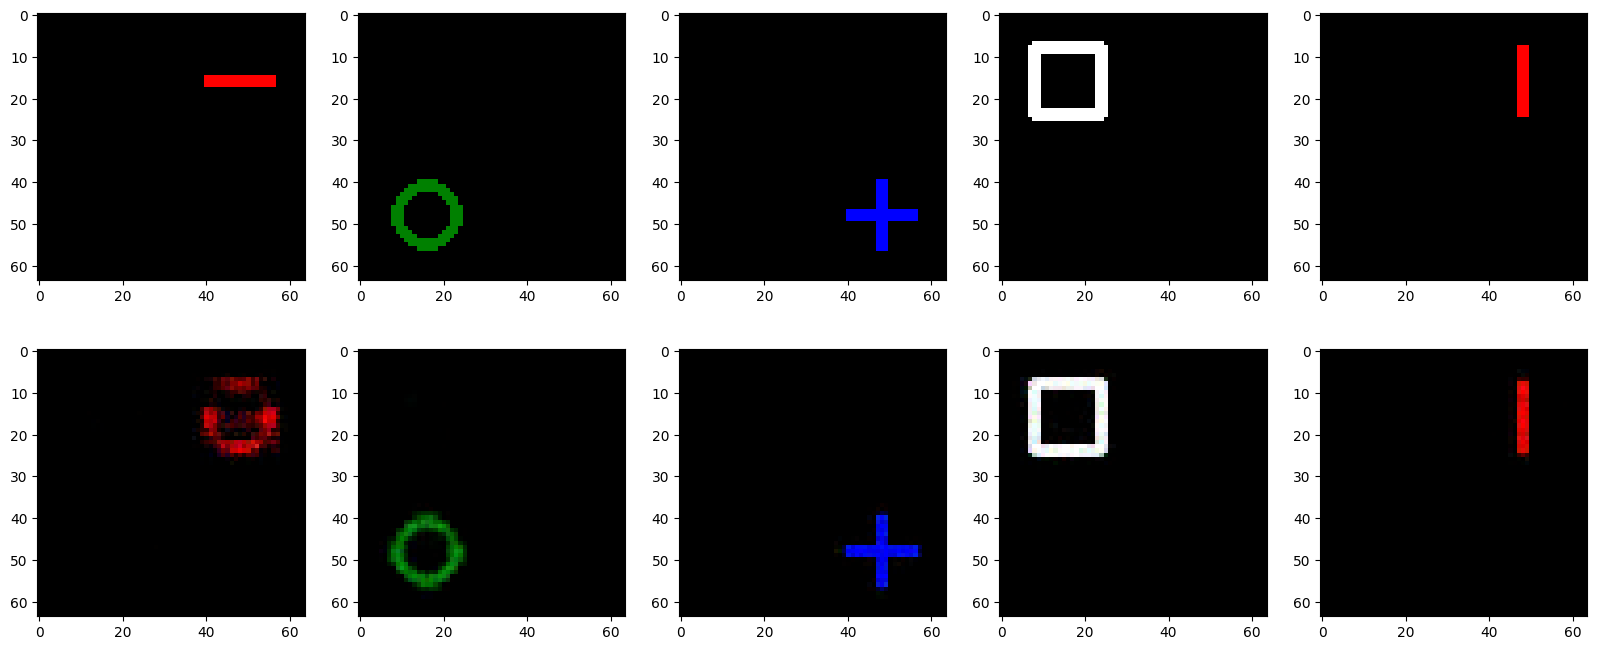

In [8]:
for batch in val_loader:
    imgs, latents, contexts = batch
    out,cnn_encoded,rnn_out,_ = model(imgs)

    fix,ax = plt.subplots(2,5, figsize=(20,8))
    for i in range(5):
        ax[0][i].imshow(imgs[i+1,0].cpu().numpy().transpose(1,2,0))
        ax[1][i].imshow(out[i,0].detach().cpu().numpy().transpose(1,2,0))
    break

In [9]:
import torch 
from sklearn.svm import LinearSVC
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def unpack_batch(batch):
    if len(batch) == 3:
        prim_sequence_inputs, latents, contexts = batch
    else:   
        prim_sequence_inputs, latents = batch
    prim_sequence_inputs = prim_sequence_inputs.transpose(0,1).to(DEVICE)
    latents = latents.transpose(0,1).to(DEVICE)
    return prim_sequence_inputs, latents

def disentanglement_metric(
            config,
             model,
             train_loader,
             val_loader,
             idx_to_classify):
    
    model.train()
    def get_activity_and_labels_b(loader):
        acti = []
        labels = []
        with torch.no_grad():
            for batch in loader:
                prim_sequence_inputs, latents = unpack_batch(batch)
                _,_,activity,_ = model(prim_sequence_inputs)
                acti.append(activity[-1:].cpu().flatten(0,1))
                labels.append(latents[-1:].cpu().flatten(0,1))
        return torch.cat(acti, dim=0), torch.cat(labels, dim=0)

    train_activities, train_latents = get_activity_and_labels_b(train_loader)
    val_activities, val_latents = get_activity_and_labels_b(val_loader)
    classifier =  LinearSVC(max_iter=5000,penalty="l1",C=10,random_state=0)
    classifier.fit(train_activities.numpy(), train_latents[:,idx_to_classify].cpu().numpy())
    latent_neurons = torch.abs(torch.from_numpy(classifier.coef_)).sum(dim=0) > 0
    train_acc = classifier.score(train_activities.numpy(), train_latents[:,idx_to_classify].cpu().numpy())
    val_acc = classifier.score(val_activities.numpy(), val_latents[:,idx_to_classify].cpu().numpy())

    return train_acc, val_acc,latent_neurons


def neurons_for_dynamic(
            config,
             model,
             train_loader,
             val_loader,
             latent_idx,
             ):
    
    model.train()
    def get_activity_and_labels_b(loader):
        acti = []
        labels = []
        with torch.no_grad():
            for batch in loader:
                prim_sequence_inputs, latents = unpack_batch(batch)
                _,_,activity,_ = model(prim_sequence_inputs)
                acti.append(activity[-1:].cpu().flatten(0,1))
                labels.append(latents[-1:].cpu().flatten(0,1))
        return torch.cat(acti, dim=0), torch.cat(labels, dim=0)

    train_activities, train_latents = get_activity_and_labels_b(train_loader)
    val_activities, val_latents = get_activity_and_labels_b(val_loader)
    classifier =  LinearSVC(max_iter=5000,penalty="l1",C=10,random_state=0)
    classifier.fit(train_activities.numpy(), train_latents[:,idx_to_classify].cpu().numpy())
    latent_neurons = torch.abs(torch.from_numpy(classifier.coef_)).sum(dim=0) > 0
    train_acc = classifier.score(train_activities.numpy(), train_latents[:,idx_to_classify].cpu().numpy())
    val_acc = classifier.score(val_activities.numpy(), val_latents[:,idx_to_classify].cpu().numpy())

    return train_acc, val_acc,latent_neurons



In [10]:
latents = ["primitive", "color", "quadrant"]
latent_idx = 0

In [11]:
latents_to_neurons = defaultdict(torch.Tensor)
train_accs = {}
val_accs = {}
for lat in classification_metric_train_loaders.keys():
    classification_metric_train_loader,lat_idx = classification_metric_train_loaders[lat]
    classification_metric_val_loader = classification_metric_val_loaders[lat][0]
    train_acc,val_acc,latent_neurons = disentanglement_metric(config, model, idx_to_classify=lat_idx, train_loader=classification_metric_train_loader, val_loader=classification_metric_val_loader)
    latents_to_neurons[lat] = latent_neurons
    train_accs[lat] = train_acc
    val_accs[lat] = val_acc
    print(f"Latent: {lat}, Train acc: {train_acc}, Val acc: {val_acc}, Num neurons: {latent_neurons.sum().item()}")

/home/ghb24/miniconda3/envs/pre/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Latent: primitive, Train acc: 1.0, Val acc: 1.0, Num neurons: 35
Latent: color, Train acc: 1.0, Val acc: 1.0, Num neurons: 20
Latent: position, Train acc: 1.0, Val acc: 1.0, Num neurons: 20


In [ ]:
import numpy as np
import torch
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


@torch.no_grad()
def _collect_stepwise_Xy_for_latent_change(
    model,
    loader,
    latent_idx_or_slice,
    *,
    subsample_batch=1,
    eps=1e-6,
    feature="delta_activity",   # "delta_activity" or "activity"
    require_exactly_one=False,
    other_latent_slices=None,   # list of slices/idx for other latents if require_exactly_one=True
):
    """
    Returns X [M,N], y [M] where y=1 if target latent changes from t->t+1.

    - feature="delta_activity": X_t = h_{t+1}-h_t
    - feature="activity":       X_t = h_t
    """
    model.eval()
    Xs, ys = [], []

    # normalize latent index input
    def _as_slice(x):
        if isinstance(x, (int, np.integer)):
            return slice(int(x), int(x) + 1)
        return x

    target_sl = _as_slice(latent_idx_or_slice)
    other_sls = None
    if other_latent_slices is not None:
        other_sls = [_as_slice(s) for s in other_latent_slices]

    for batch in loader:
        imgs, latents, contexts = batch             # [T,B,...], [T,B,L]
        if subsample_batch < 1:
            B = imgs.shape[1]
            idx = torch.randperm(B)[:max(2, int(subsample_batch * B))]
            imgs = imgs[:, idx]
            latents = latents[:, idx]
            contexts = contexts[idx]
        _, _, activity, _ = model(imgs)  
        # expected [T,B,N]
        A = activity.detach().cpu()               # [T,B,N]
        L = latents.detach().cpu()                    # [T,B,L]

        dL = contexts.unsqueeze(0).repeat(A.shape[0] - 1, 1, 1).cpu()  # [T-1,B,L]
        dA = A[1:] - A[:-1]                       # [T-1,B,N]

        # y: target latent changed?
        y = (dL[..., target_sl].abs().amax(dim=-1) > eps)  # [T-1,B], bool

        if require_exactly_one:
            if other_sls is None:
                raise ValueError("require_exactly_one=True needs other_latent_slices=[...]")
            changed_others = []
            for sl in other_sls:
                changed_others.append(dL[..., sl].abs().amax(dim=-1) > eps)  # [T-1,B]
            changed_others = torch.stack(changed_others, dim=-1)          # [T-1,B,K]
            # keep only steps where target changed XOR others didn't change:
            keep = (y & (changed_others.sum(dim=-1) == 0))
        else:
            keep = torch.ones_like(y, dtype=torch.bool)

        if feature == "delta_activity":
            X = dA
        elif feature == "activity":
            X = A[:-1]
        else:
            raise ValueError("feature must be 'delta_activity' or 'activity'")

        X = X[keep].reshape(-1, X.shape[-1])      # [M,N]
        y = y[keep].reshape(-1).to(torch.int64)   # [M]

        if X.numel() == 0:
            continue

        Xs.append(X)
        ys.append(y)

    if len(Xs) == 0:
        raise RuntimeError("No samples collected. Check eps/require_exactly_one/latent slices.")

    X = torch.cat(Xs, dim=0).numpy()
    y = torch.cat(ys, dim=0).numpy()
    print(f"Collected {X.shape[0]} samples with {X.shape[1]} features for latent_idx_or_slice={latent_idx_or_slice}")
    return X, y


def dynamic_neuron_superset_stability(
    model,
    train_loader,
    val_loader,
    latent_idx_or_slice,
    *,
    subsample_batch=1,
    eps=1e-6,
    feature="delta_activity",
    require_exactly_one=False,
    other_latent_slices=None,
    # stability selection params
    n_boot=100,
    sample_frac=0.8,
    C_grid=(0.05, 0.1, 0.3, 1.0, 3.0, 10.0),
    freq_threshold=0.2,
    max_iter=5000,
    random_state=0,
):
    """
    Finds a *superset* of neurons coding for the dynamics (change) of a latent via
    union/stability selection over sparse multivariate models.

    Returns dict with:
      - freq: [N] selection frequency
      - union_mask: [N] bool
      - stable_mask: [N] bool (freq >= freq_threshold)
      - avg_abs_w: [N] avg |weight| over fits where selected
      - ranked_neurons: list of neuron indices (most frequent first)
      - train_acc_mean, val_acc_mean: mean accuracies over successful fits
      - n_fits_success: number of successful fits
    """
    # build datasets
    Xtr, ytr = _collect_stepwise_Xy_for_latent_change(
        model, train_loader, latent_idx_or_slice,
        eps=eps, feature=feature,
        require_exactly_one=require_exactly_one,
        other_latent_slices=other_latent_slices,
        subsample_batch=subsample_batch,
    )
    Xva, yva = _collect_stepwise_Xy_for_latent_change(
        model, val_loader, latent_idx_or_slice,
        eps=eps, feature=feature,
        require_exactly_one=require_exactly_one,
        other_latent_slices=other_latent_slices,
        subsample_batch=subsample_batch,
    )

    M, N = Xtr.shape
    rng = np.random.default_rng(random_state)

    selected_counts = np.zeros(N, dtype=np.int64)
    absw_sums = np.zeros(N, dtype=np.float64)
    absw_counts = np.zeros(N, dtype=np.int64)

    train_accs, val_accs = [], []
    n_success = 0

    # precompute indices for speed
    n_sub = max(2, int(sample_frac * M))

    for b in range(n_boot):
        
        idx = rng.integers(0, M, size=n_sub)  # bootstrap w/ replacement
        Xb, yb = Xtr[idx], ytr[idx]
        # skip degenerate bootstraps (all one class)
        if np.unique(yb).size < 2:
            continue
        print(f"Bootstrap {b}: training logistic regression with {Xb.shape[0]} samples...")
        for C in C_grid:
            clf = make_pipeline(
                StandardScaler(),
                LogisticRegression(
                    penalty="l1",
                    solver="saga",
                    C=float(C),
                    max_iter=max_iter,
                    random_state=(random_state + 1000 * b + int(10 * C)),
                ),
            )

            try:
                clf.fit(Xb, yb)
            except Exception:
                continue

            w = clf.named_steps["logisticregression"].coef_.reshape(-1)  # [N]
            nz = np.abs(w) > 1e-12

            selected_counts[nz] += 1
            absw_sums[nz] += np.abs(w[nz])
            absw_counts[nz] += 1

            train_accs.append(clf.score(Xb, yb))
            val_accs.append(clf.score(Xva, yva))
            n_success += 1

    if n_success == 0:
        raise RuntimeError("All fits failed/skipped. Try larger sample_frac, smaller eps, or fewer constraints.")

    freq = selected_counts / float(n_success)
    union_mask = freq > 0
    stable_mask = freq >= float(freq_threshold)
    avg_abs_w = np.zeros(N, dtype=np.float64)
    ok = absw_counts > 0
    avg_abs_w[ok] = absw_sums[ok] / absw_counts[ok]

    # rank by (freq, avg_abs_w)
    ranked_neurons = np.lexsort((-avg_abs_w, -freq)).tolist()

    return {
        "freq": freq,
        "union_mask": union_mask,
        "stable_mask": stable_mask,
        "avg_abs_w": avg_abs_w,
        "ranked_neurons": ranked_neurons,
        "train_acc_mean": float(np.mean(train_accs)),
        "val_acc_mean": float(np.mean(val_accs)),
        "n_fits_success": int(n_success),
        "X_shape": Xtr.shape,
        "feature": feature,
        "eps": eps,
        "require_exactly_one": require_exactly_one,
    }

In [ ]:
out = dynamic_neuron_superset_stability(
    model, analysis_loader, val_loader,
    subsample_batch=0.2,
    latent_idx_or_slice=0,          # “position” column
    feature="activity",       # best for dynamics
    n_boot=100,
    C_grid=(0.05, 0.1, 0.3, 1, 3),
    freq_threshold=0.2,
)
pos_union = np.where(out["union_mask"])[0]
pos_stable = np.where(out["stable_mask"])[0]
top20 = out["ranked_neurons"][:20]

Collected 6750 samples with 512 features for latent_idx_or_slice=0
Collected 1375 samples with 512 features for latent_idx_or_slice=0
